<a href="https://colab.research.google.com/github/divyamanjuatla/Student-Performance-Analysis-Dashboard/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
dfs=pd.read_csv('/content/student_data.csv',encoding='latin1')
dfs

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [ ]:
dfs.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [ ]:
dfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [ ]:
dfs.isnull().sum()

,0
Unnamed: 0,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572


In [ ]:

d={'NrSiblings':'No_ofSiblings',
   'TransportMeans':'ModeOfTransport',
   'IsFirstChild': 'FirstChild',
   'PracticeSport': 'SportsParticipation',
   'ParentEduc': 'ParentEducation',
   'ParentMaritalStatus': 'ParentMarital_Status',
   'WklyStudyHours': 'WeeklyStudyHours'}
dfs.rename(columns=d,inplace=True)
dfs


,Unnamed: 0,Gender,EthnicGroup,ParentEducation,LunchType,TestPrep,ParentMarital_Status,SportsParticipation,FirstChild,No_ofSiblings,ModeOfTransport,WeeklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [ ]:
dfs[dfs.duplicated()]

,Unnamed: 0,Gender,EthnicGroup,ParentEducation,LunchType,TestPrep,ParentMarital_Status,SportsParticipation,FirstChild,No_ofSiblings,ModeOfTransport,WeeklyStudyHours,MathScore,ReadingScore,WritingScore


In [ ]:
dfs

,Unnamed: 0,Gender,EthnicGroup,ParentEducation,LunchType,TestPrep,ParentMarital_Status,SportsParticipation,FirstChild,No_ofSiblings,ModeOfTransport,WeeklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [ ]:
dfs.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
dfs

,Gender,EthnicGroup,ParentEducation,LunchType,TestPrep,ParentMarital_Status,SportsParticipation,FirstChild,No_ofSiblings,ModeOfTransport,WeeklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [ ]:
dfs['No_ofSiblings'] = dfs['No_ofSiblings'].fillna(dfs['No_ofSiblings'].median())
dfs

,Gender,EthnicGroup,ParentEducation,LunchType,TestPrep,ParentMarital_Status,SportsParticipation,FirstChild,No_ofSiblings,ModeOfTransport,WeeklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,group C,bachelor's degree,standard,none,married,regularly,yes,3,school_bus,< 5,71,71,74
1,female,group C,some college,standard,none,married,sometimes,yes,0,school_bus,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1,school_bus,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,female,group D,high school,standard,none,single,sometimes,no,2,school_bus,5 - 10,59,61,65
30637,male,group E,high school,standard,none,single,regularly,no,1,private,5 - 10,58,53,51
30638,female,group C,high school,free/reduced,completed,married,sometimes,no,1,private,5 - 10,61,70,67
30639,female,group D,associate's degree,standard,completed,married,regularly,no,3,school_bus,5 - 10,82,90,93


In [ ]:
dfs['EthnicGroup'] = dfs['EthnicGroup'].fillna(dfs['EthnicGroup'].mode()[0])

dfs['ParentEducation'] = dfs['ParentEducation'].fillna(dfs['ParentEducation'].mode()[0])

dfs['TestPrep'] = dfs['TestPrep'].fillna(dfs['TestPrep'].mode()[0])

dfs['ParentMarital_Status'] = dfs['ParentMarital_Status'].fillna(dfs['ParentMarital_Status'].mode()[0])

dfs['SportsParticipation'] = dfs['SportsParticipation'].fillna(dfs['SportsParticipation'].mode()[0])

dfs['FirstChild'] = dfs['FirstChild'].fillna(dfs['FirstChild'].mode()[0])

dfs['ModeOfTransport'] = dfs['ModeOfTransport'].fillna(dfs['ModeOfTransport'].mode()[0])

dfs['WeeklyStudyHours'] = dfs['WeeklyStudyHours'].fillna(dfs['WeeklyStudyHours'].mode()[0])

dfs['No_ofSiblings'] = dfs['No_ofSiblings'].fillna(dfs['No_ofSiblings'].median())



In [ ]:
dfs['No_ofSiblings']=dfs['No_ofSiblings'].astype(int)
dfs

,Gender,EthnicGroup,ParentEducation,LunchType,TestPrep,ParentMarital_Status,SportsParticipation,FirstChild,No_ofSiblings,ModeOfTransport,WeeklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,group C,bachelor's degree,standard,none,married,regularly,yes,3,school_bus,< 5,71,71,74
1,female,group C,some college,standard,none,married,sometimes,yes,0,school_bus,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1,school_bus,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,female,group D,high school,standard,none,single,sometimes,no,2,school_bus,5 - 10,59,61,65
30637,male,group E,high school,standard,none,single,regularly,no,1,private,5 - 10,58,53,51
30638,female,group C,high school,free/reduced,completed,married,sometimes,no,1,private,5 - 10,61,70,67
30639,female,group D,associate's degree,standard,completed,married,regularly,no,3,school_bus,5 - 10,82,90,93


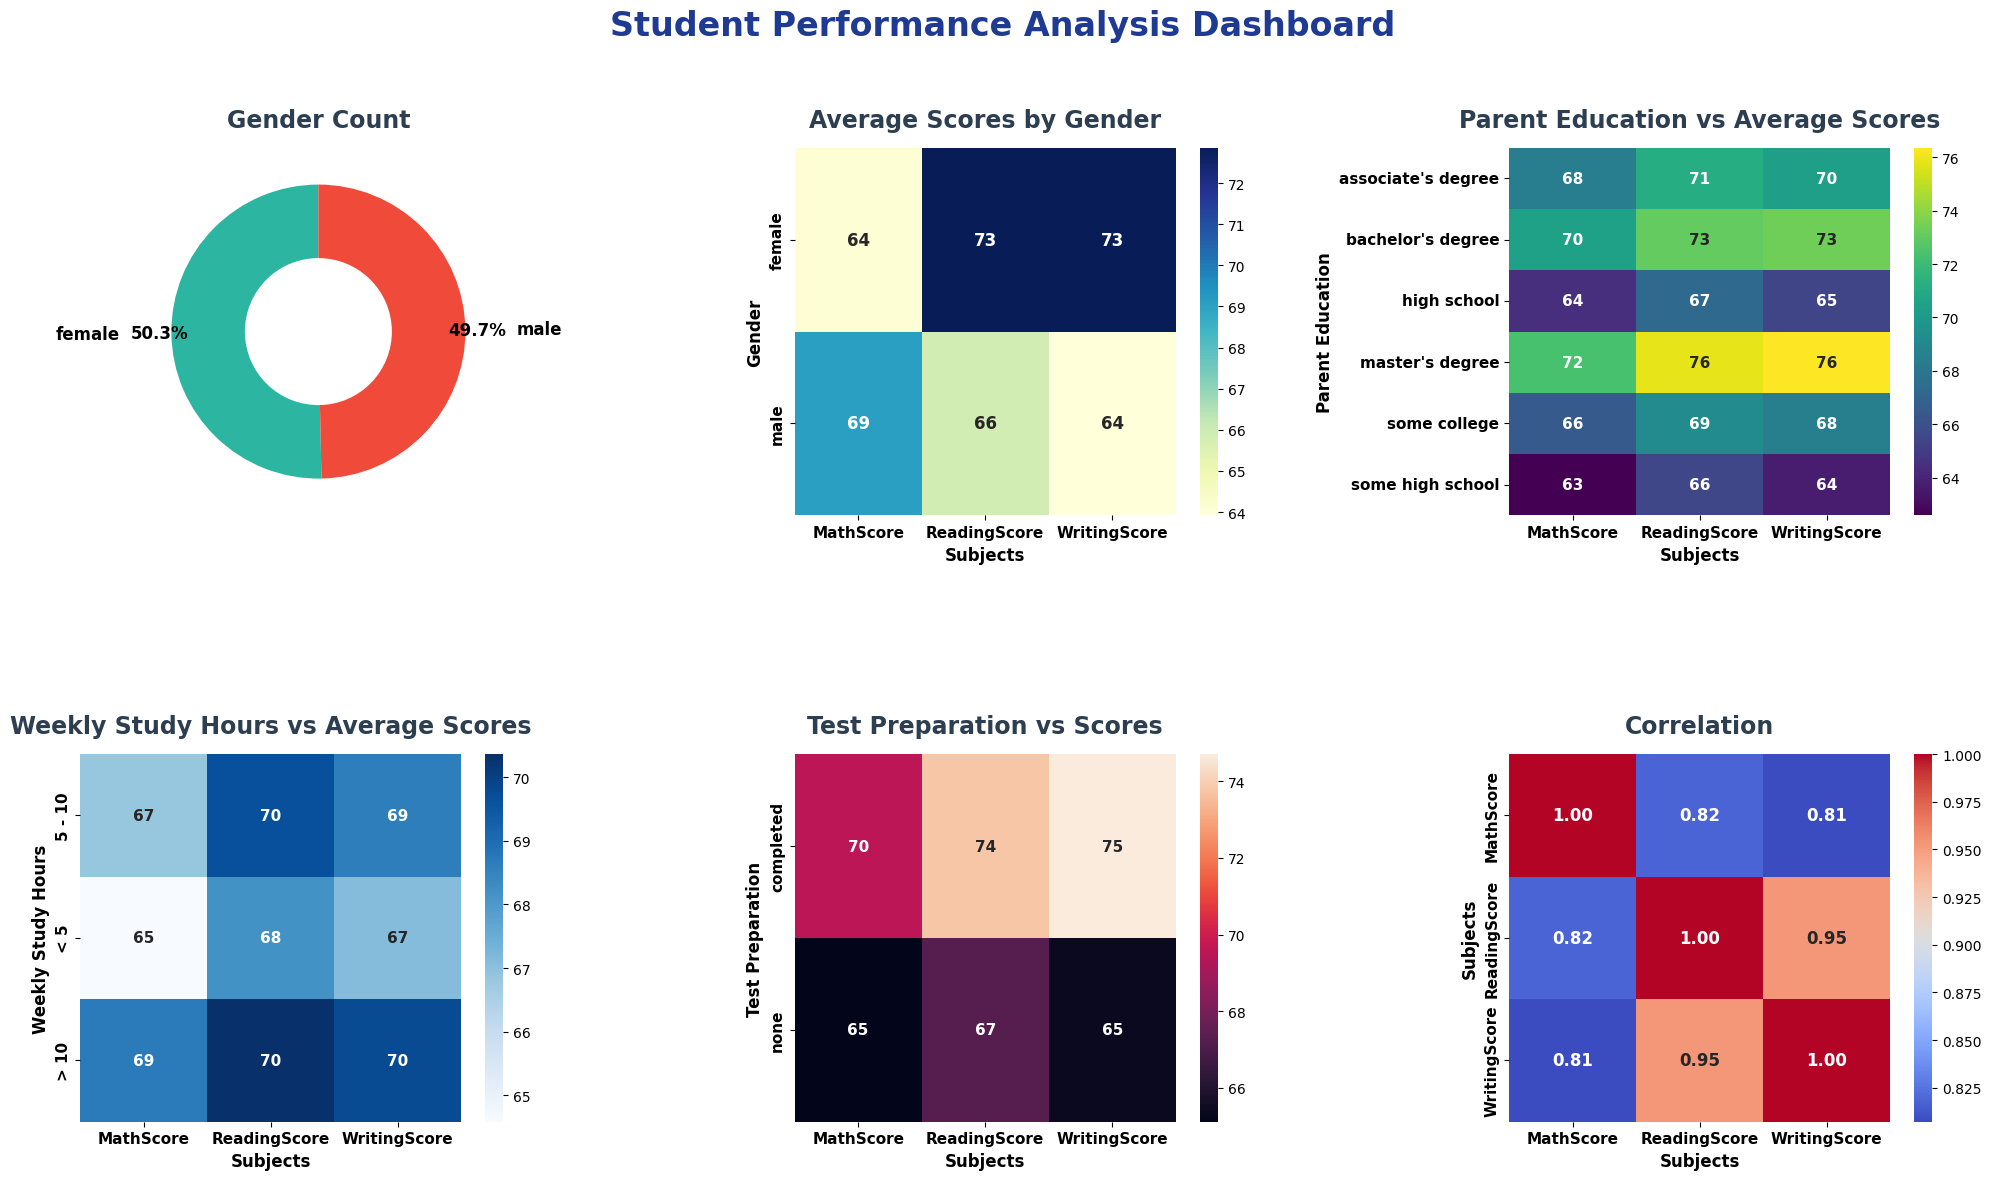

In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'

# Create figure
fig, ax = plt.subplots(2, 3, figsize=(20, 12))

# Dashboard Title
fig.suptitle(
    "Student Performance Analysis Dashboard",
    fontsize=24,
    fontweight='bold',
    color='#1F3A93'
)

# ===========================
# 1. Gender Count (Donut Chart)
# ===========================

gender_count = dfs['Gender'].value_counts()

ax[0,0].pie(
    gender_count,
    labels=gender_count.index,
    colors=['#2CB5A0','#F04A3A'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.50),
    pctdistance=1.08,
    labeldistance=1.35,
    textprops={
        'fontsize':12,
        'fontweight':'bold'
    }
)

ax[0,0].set_title(
    "Gender Count",
    fontsize=17,
    fontweight='bold',
    color='#2C3E50',
    pad=15
)

# ===========================
# 2. Average Scores by Gender
# ===========================

gender_avg = dfs.groupby('Gender')[
    ['MathScore','ReadingScore','WritingScore']
].mean()

sns.heatmap(
    gender_avg,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    annot_kws={
        "fontsize":12,
        "fontweight":"bold"
    },
    ax=ax[0,1]
)

ax[0,1].set_title(
    "Average Scores by Gender",
    fontsize=17,
    fontweight='bold',
    color='#2C3E50',
    pad=15
)

ax[0,1].set_xlabel(
    "Subjects",
    fontsize=12,
    fontweight='bold'
)

ax[0,1].set_ylabel(
    "Gender",
    fontsize=12,
    fontweight='bold'
)

plt.setp(ax[0,1].get_xticklabels(),
         fontsize=11,
         fontweight='bold')

plt.setp(ax[0,1].get_yticklabels(),
         fontsize=11,
         fontweight='bold')

# ===========================
# 3. Parent Education
# ===========================

parent_avg = dfs.groupby('ParentEducation')[
    ['MathScore','ReadingScore','WritingScore']
].mean()

sns.heatmap(
    parent_avg,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    annot_kws={
        "fontsize":11,
        "fontweight":"bold"
    },
    ax=ax[0,2]
)

ax[0,2].set_title(
    "Parent Education vs Average Scores",
    fontsize=17,
    fontweight='bold',
    color='#2C3E50',
    pad=15
)

ax[0,2].set_xlabel(
    "Subjects",
    fontsize=12,
    fontweight='bold'
)

ax[0,2].set_ylabel(
    "Parent Education",
    fontsize=12,
    fontweight='bold'
)

plt.setp(ax[0,2].get_xticklabels(),
         fontsize=11,
         fontweight='bold')

plt.setp(ax[0,2].get_yticklabels(),
         fontsize=11,
         fontweight='bold')

# ===========================
# 4. Weekly Study Hours
# ===========================

study_avg = dfs.groupby('WeeklyStudyHours')[
    ['MathScore','ReadingScore','WritingScore']
].mean()

sns.heatmap(
    study_avg,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    annot_kws={
        "fontsize":11,
        "fontweight":"bold"
    },
    ax=ax[1,0]
)

ax[1,0].set_title(
    "Weekly Study Hours vs Average Scores",
    fontsize=17,
    fontweight='bold',
    color='#2C3E50',
    pad=15
)

ax[1,0].set_xlabel(
    "Subjects",
    fontsize=12,
    fontweight='bold'
)

ax[1,0].set_ylabel(
    "Weekly Study Hours",
    fontsize=12,
    fontweight='bold'
)

plt.setp(ax[1,0].get_xticklabels(),
         fontsize=11,
         fontweight='bold')

plt.setp(ax[1,0].get_yticklabels(),
         fontsize=11,
         fontweight='bold')

# ===========================
# 5. Test Preparation
# ===========================

test_avg = dfs.groupby('TestPrep')[
    ['MathScore','ReadingScore','WritingScore']
].mean()

sns.heatmap(
    test_avg,
    annot=True,
    fmt=".0f",
    cmap="rocket",
    annot_kws={
        "fontsize":11,
        "fontweight":"bold"
    },
    ax=ax[1,1]
)

ax[1,1].set_title(
    "Test Preparation vs Scores",
    fontsize=17,
    fontweight='bold',
    color='#2C3E50',
    pad=15
)

ax[1,1].set_xlabel(
    "Subjects",
    fontsize=12,
    fontweight='bold'
)

ax[1,1].set_ylabel(
    "Test Preparation",
    fontsize=12,
    fontweight='bold'
)

plt.setp(ax[1,1].get_xticklabels(),
         fontsize=11,
         fontweight='bold')

plt.setp(ax[1,1].get_yticklabels(),
         fontsize=11,
         fontweight='bold')

# ===========================
# 6. Correlation Heatmap
# ===========================

corr = dfs[
    ['MathScore','ReadingScore','WritingScore']
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={
        "fontsize":12,
        "fontweight":"bold"
    },
    ax=ax[1,2]
)

ax[1,2].set_title(
    "Correlation",
    fontsize=17,
    fontweight='bold',
    color='#2C3E50',
    pad=15
)

ax[1,2].set_xlabel(
    "Subjects",
    fontsize=12,
    fontweight='bold'
)

ax[1,2].set_ylabel(
    "Subjects",
    fontsize=12,
    fontweight='bold'
)

plt.setp(ax[1,2].get_xticklabels(),
         fontsize=11,
         fontweight='bold')

plt.setp(ax[1,2].get_yticklabels(),
         fontsize=11,
         fontweight='bold')

# ===========================
# Dashboard Spacing
# ===========================

plt.tight_layout(rect=[0,0,1,0.95])

plt.subplots_adjust(
    hspace=0.65,
    wspace=0.50
)

fig.savefig('student_performance_dashboard.png', dpi=300)

plt.show()

Overall Project Conclusion
What I understood from the analysis

After cleaning the dataset and performing Exploratory Data Analysis (EDA), I found that several factors influence student performance.

The dataset has a balanced distribution of male and female students.
Male students performed better in Mathematics, while female students achieved higher scores in Reading and Writing.
Students with parents who have higher educational qualifications generally scored better.
Students who studied more hours per week achieved higher average scores.
Completing test preparation was associated with improved performance in all three subjects.
Reading and Writing scores have a strong positive correlation, indicating that students who perform well in one language subject often perform well in the other.